# Phase 2 · Data Cleaning & Preprocessing

**Goal**: Transform raw Nepali banking data into a canonical schema ready for
synthetic data generation and multi-agent detection.

**Outputs** (saved to `data/interim/`):
| File | Description |
|---|---|
| `transactions.parquet` | Canonical base schema |
| `accounts.parquet` | Canonical accounts |
| `schema2_location.parquet` | Schema 2: location consolidation |
| `schema3_label_encoded.parquet` | Schema 3: label encoding |
| `schema4_quantile_amount.parquet` | Schema 4: quantile binning of amount |
| `schema5_cbrt_amount.parquet` | Schema 5: cubic root amount transform |

Schemas 2–5 follow the methodology in the reference paper (TechRxiv preprint)
for benchmarking synthetic data generators with different preprocessing strategies.


In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 2 · Imports & Environment Setup
# ──────────────────────────────────────────────────────────────────────────────
import os, sys, logging, warnings, xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("phase2")

# ── Resolve project root ──────────────────────────────────────────────────────
if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    PROJECT_ROOT = Path("/kaggle/working/neural-sentinel")
    KAGGLE_MODE  = True
else:
    PROJECT_ROOT = Path(os.getcwd()).resolve()
    while not (PROJECT_ROOT / "AGENTS.md").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    KAGGLE_MODE = False

sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR    = PROJECT_ROOT / "data" / "original"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Kaggle mode  : {KAGGLE_MODE}")
print(f"Interim dir  : {INTERIM_DIR}")
print("\n✓ Imports complete")


Project root : /home/red/Desktop/neural-sentinel
Kaggle mode  : False
Interim dir  : /home/red/Desktop/neural-sentinel/data/interim

✓ Imports complete


## 1. Load Raw Data

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 3 · Load Raw Files
# ──────────────────────────────────────────────────────────────────────────────
%time

tx_df  = pd.read_csv(DATA_DIR / "transactions.csv")
acc_df = pd.read_csv(DATA_DIR / "accounts.csv")
ml_df  = pd.read_csv(DATA_DIR / "ml_features.csv")

print(f"transactions.csv  : {tx_df.shape[0]:,} rows × {tx_df.shape[1]} cols")
print(f"accounts.csv      : {acc_df.shape[0]:,} rows × {acc_df.shape[1]} cols")
print(f"ml_features.csv   : {ml_df.shape[0]:,} rows × {ml_df.shape[1]} cols")
print()
print("Transactions dtypes:")
print(tx_df.dtypes.to_string())


CPU times: user 4 μs, sys: 0 ns, total: 4 μs
Wall time: 6.68 μs
transactions.csv  : 100,222 rows × 55 cols
accounts.csv      : 65,339 rows × 13 cols
ml_features.csv   : 100,222 rows × 35 cols

Transactions dtypes:
row_index                      int64
Date                          object
Time                          object
Sender_account                 int64
Receiver_account               int64
Amount                       float64
Payment_currency              object
Received_currency             object
Sender_bank_location          object
Receiver_bank_location        object
Payment_type                  object
transmode_code                object
fx_rate_to_npr               float64
amount_local_npr             float64
sender_country_risk          float64
receiver_country_risk        float64
cross_border_flag              int64
currency_mismatch              int64
sender_institution            object
sender_branch                 object
sender_account_number         object
sender_ac

## 2. Data Quality Report

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 4 · Data Quality Report — Nulls, Duplicates, Ranges
# ──────────────────────────────────────────────────────────────────────────────

def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame({
        "dtype":   df.dtypes,
        "nulls":   df.isnull().sum(),
        "null_%":  (df.isnull().mean() * 100).round(2),
        "unique":  df.nunique(),
        "min":     df.select_dtypes(include="number").min().reindex(df.columns),
        "max":     df.select_dtypes(include="number").max().reindex(df.columns),
    })
    print(f"\n{'='*60}")
    print(f" Quality report: {name}  ({len(df):,} rows × {len(df.columns)} cols)")
    print(f"{'='*60}")
    print(report.to_string())
    dup_count = df.duplicated().sum()
    print(f"\nDuplicate rows: {dup_count:,}")
    return report

tx_report  = quality_report(tx_df,  "transactions.csv")
acc_report = quality_report(acc_df, "accounts.csv")



 Quality report: transactions.csv  (100,222 rows × 55 cols)
                             dtype  nulls  null_%  unique            min           max
row_index                    int64      0     0.0  100222       0.000000  1.002210e+05
Date                        object      0     0.0      10            NaN           NaN
Time                        object      0     0.0   53208            NaN           NaN
Sender_account               int64      0     0.0   22310   92172.000000  9.000000e+11
Receiver_account             int64      0     0.0   46586  124082.000000  9.000000e+11
Amount                     float64      0     0.0   96566       8.880000  2.688045e+06
Payment_currency            object      0     0.0      13            NaN           NaN
Received_currency           object      0     0.0      13            NaN           NaN
Sender_bank_location        object      0     0.0      18            NaN           NaN
Receiver_bank_location      object      0     0.0      18            

## 3. Fraud Label Derivation

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 5 · Derive is_fraud — Primary: ml_features.csv, Cross-check: XML STRs
# ──────────────────────────────────────────────────────────────────────────────

# ── Primary source: ml_features.csv ──────────────────────────────────────────
# ml_features.csv is row-aligned with transactions.csv (same index).
# The `is_suspicious_tx` column is the ground-truth fraud label derived from
# the bank's internal STR filing process.
is_fraud_primary = ml_df["is_suspicious_tx"].astype(int).values
print(f"Primary label  (ml_features): {is_fraud_primary.sum():,} flagged / {len(is_fraud_primary):,} total")
print(f"Fraud rate (primary)         : {is_fraud_primary.mean():.4%}")

# ── Secondary source: XML STR Reports ────────────────────────────────────────
# Parse all XML reports in data/original/reports/ to cross-validate.
# Each report's <internal_ref_number> is formatted INT-{report_num}-{row_index}.
reports_dir  = DATA_DIR / "reports"
xml_files    = list(reports_dir.glob("*.xml"))
flagged_rows = set()

for xf in xml_files:
    try:
        tree = ET.parse(xf)
        root = tree.getroot()
        for tx in root.findall(".//transaction"):
            ref = tx.findtext("internal_ref_number") or ""
            parts = ref.split("-")
            if len(parts) == 3:
                try:
                    flagged_rows.add(int(parts[2]))
                except ValueError:
                    pass
    except ET.ParseError:
        print(f"  Warning: could not parse {xf.name}")

n = len(tx_df)
is_fraud_xml = np.zeros(n, dtype=np.int8)
valid_refs   = [i for i in flagged_rows if 0 <= i < n]
is_fraud_xml[valid_refs] = 1

print(f"\nXML STR reports: {len(xml_files)} files → {len(flagged_rows)} references → {len(valid_refs)} valid row indices")
print(f"XML label              : {is_fraud_xml.sum():,} flagged")

# ── Agreement analysis ────────────────────────────────────────────────────────
both      = int(np.logical_and(is_fraud_primary, is_fraud_xml).sum())
only_ml   = int(np.logical_and(is_fraud_primary, ~is_fraud_xml.astype(bool)).sum())
only_xml  = int(np.logical_and(~is_fraud_primary.astype(bool), is_fraud_xml).sum())

print(f"\nLabel agreement:")
print(f"  Both sources agree (fraud)  : {both:,}")
print(f"  Only ml_features flags      : {only_ml:,}")
print(f"  Only XML flags              : {only_xml:,}")

# ── Final label: union of both sources ───────────────────────────────────────
is_fraud_final = np.maximum(is_fraud_primary, is_fraud_xml).astype(int)
print(f"\nFinal label (union)    : {is_fraud_final.sum():,} flagged / {n:,} total")
print(f"Final fraud rate       : {is_fraud_final.mean():.4%}")


Primary label  (ml_features): 336 flagged / 100,222 total
Fraud rate (primary)         : 0.3353%

XML STR reports: 276 files → 336 references → 336 valid row indices
XML label              : 336 flagged

Label agreement:
  Both sources agree (fraud)  : 336
  Only ml_features flags      : 0
  Only XML flags              : 0

Final label (union)    : 336 flagged / 100,222 total
Final fraud rate       : 0.3353%


## 4. Canonical Schema Transformation

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 6 · Build Canonical Transactions Table
# ──────────────────────────────────────────────────────────────────────────────
import uuid

# ── Lookup maps ───────────────────────────────────────────────────────────────
CURRENCY_MAP = {
    "UK pounds": "GBP", "US Dollar": "USD", "Euro": "EUR",
    "Qatari Rial": "QAR", "Indian Rupee": "INR", "Saudi Riyal": "SAR",
    "UAE Dirham": "AED", "NPR": "NPR", "Nepalese Rupee": "NPR",
}
TRANSMODE_CHANNEL_MAP = {
    "A": "branch", "B": "branch", "E": "online_banking",
    "F": "online_banking", "J": "mobile_banking", "P": "pos", "Z": "atm",
}
RISK_MAP = {
    "RISK-LOW": "low", "RISK-MED": "medium",
    "RISK-MEDIUM": "medium", "RISK-HIGH": "high",
}
KNOWN_CORRIDORS = {
    frozenset(["Qatar",        "Nepal"]): "Qatar->Nepal",
    frozenset(["India",        "Nepal"]): "India->Nepal",
    frozenset(["UAE",          "Nepal"]): "UAE->Nepal",
    frozenset(["Malaysia",     "Nepal"]): "Malaysia->Nepal",
    frozenset(["Saudi Arabia", "Nepal"]): "Saudi Arabia->Nepal",
    frozenset(["USA",          "Nepal"]): "USA->Nepal",
    frozenset(["UK",           "Nepal"]): "UK->Nepal",
    frozenset(["Japan",        "Nepal"]): "Japan->Nepal",
    frozenset(["South Korea",  "Nepal"]): "South Korea->Nepal",
    frozenset(["Australia",    "Nepal"]): "Australia->Nepal",
}

def map_tx_type(row):
    ptype  = str(row.get("Payment_type", "")).strip()
    is_cb  = int(row.get("cross_border_flag", 0))
    recv   = str(row.get("Receiver_bank_location", "Nepal"))
    if ptype == "Cash Withdrawal": return "cash_out"
    if ptype == "Cash Deposit":    return "deposit"
    if ptype == "ATM":             return "withdrawal"
    if ptype in ("POS", "Payment"): return "payment"
    if is_cb:
        return "remittance_inbound" if recv.strip().lower() == "nepal" else "remittance_outbound"
    return "transfer"

def get_corridor(sender, recv, is_cb):
    if not is_cb: return None
    key = frozenset([sender.strip(), recv.strip()])
    return KNOWN_CORRIDORS.get(key, f"{sender.strip()}->{recv.strip()}")

def assign_fraud_type(row):
    if not row["is_fraud"]: return None
    if row["is_cross_border"] and row["amount_npr"] > 500_000: return "aml_layering"
    if row["amount_npr"] < 1_000_000 and row["is_cross_border"]: return "aml_structuring"
    return "transaction_fraud"

# ── Assemble canonical DataFrame ──────────────────────────────────────────────
n = len(tx_df)
ctx = {}

ctx["transaction_id"]           = [str(uuid.uuid4()) for _ in range(n)]
ctx["transaction_date"]         = pd.to_datetime(tx_df["Date"],  errors="coerce").dt.date
ctx["transaction_time"]         = pd.to_datetime(tx_df["Time"],  errors="coerce").dt.time
ctx["sender_account_id"]        = tx_df["Sender_account"].astype(str)
ctx["receiver_account_id"]      = tx_df["Receiver_account"].astype(str)
ctx["transaction_type"]         = tx_df.apply(map_tx_type, axis=1)
ctx["amount_npr"]               = tx_df["amount_local_npr"].clip(lower=0.01)
ctx["original_currency"]        = tx_df["Payment_currency"].map(CURRENCY_MAP).fillna("NPR")
ctx["exchange_rate"]            = tx_df["fx_rate_to_npr"].clip(lower=0.01)
ctx["channel"]                  = tx_df["transmode_code"].map(TRANSMODE_CHANNEL_MAP).fillna("branch")
ctx["sender_country"]           = tx_df["Sender_bank_location"].fillna("Nepal")
ctx["receiver_country"]         = tx_df["Receiver_bank_location"].fillna("Nepal")
ctx["is_cross_border"]          = tx_df["cross_border_flag"].fillna(0).astype(int)
ctx["remittance_corridor"]      = tx_df.apply(
    lambda r: get_corridor(r["Sender_bank_location"], r["Receiver_bank_location"], r["cross_border_flag"]), axis=1)
ctx["merchant_category"]        = None
ctx["device_type"]              = tx_df["transmode_code"].map(TRANSMODE_CHANNEL_MAP).fillna("branch").map(
    {"atm":"atm_card","pos":"pos_terminal","mobile_banking":"mobile",
     "online_banking":"desktop","branch":"branch_terminal"}).fillna("unknown")
ctx["ip_address"]               = None
ctx["ip_country"]               = tx_df["Sender_bank_location"].fillna("Nepal")
ctx["ip_is_vpn"]                = 0
ctx["is_fraud"]                 = is_fraud_final
ctx["fraud_type"]               = None  # filled below
ctx["aml_risk_indicator"]       = 0     # filled below

# Engineered features (kept for agents, excluded from generator cols)
ctx["hour_of_day"]              = tx_df["hour_of_day"].fillna(12).astype(int)
ctx["day_of_week"]              = tx_df["day_of_week"].fillna(0).astype(int)
ctx["is_weekend"]               = tx_df["is_weekend"].fillna(0).astype(int)
ctx["month"]                    = tx_df["month"].fillna(1).astype(int)
ctx["above_1M_NPR"]             = tx_df["above_1M_NPR"].fillna(0).astype(int)
ctx["above_10M_NPR"]            = tx_df["above_10M_NPR"].fillna(0).astype(int)
ctx["velocity_sum_10tx"]        = tx_df["velocity_sum_10tx"].fillna(0)
ctx["tx_count_10"]              = tx_df["tx_count_10"].fillna(0)
ctx["tx_count_30"]              = tx_df["tx_count_30"].fillna(0)
ctx["currency_mismatch"]        = tx_df["currency_mismatch"].fillna(0).astype(int)
ctx["sender_country_risk"]      = tx_df["sender_country_risk"].fillna(0.5)
ctx["receiver_country_risk"]    = tx_df["receiver_country_risk"].fillna(0.5)
ctx["sender_pep"]               = tx_df["sender_pep"].fillna(0).astype(int)
ctx["sender_sanctions"]         = tx_df["sender_sanctions"].fillna(0).astype(int)
ctx["receiver_pep"]             = tx_df["receiver_pep"].fillna(0).astype(int)
ctx["receiver_sanctions"]       = tx_df["receiver_sanctions"].fillna(0).astype(int)
ctx["sender_risk_grade"]        = tx_df["sender_risk_grade"].map(RISK_MAP).fillna("medium")
ctx["sender_account_age_days"]  = tx_df["sender_account_age_days"].fillna(0).astype(int)
ctx["receiver_account_age_days"]= tx_df["receiver_account_age_days"].fillna(0).astype(int)

tx_canonical = pd.DataFrame(ctx)

# Derive fraud_type and aml_risk_indicator
tx_canonical["fraud_type"] = tx_canonical.apply(assign_fraud_type, axis=1)
tx_canonical["aml_risk_indicator"] = tx_canonical["fraud_type"].isin(
    ["aml_layering","aml_structuring","aml_mule_network"]).astype(int)

print(f"Canonical transactions shape: {tx_canonical.shape}")
print(f"\nColumn dtypes:")
print(tx_canonical.dtypes.to_string())
print(f"\nFraud breakdown:")
print(tx_canonical["fraud_type"].value_counts(dropna=False))


Canonical transactions shape: (100222, 41)

Column dtypes:
transaction_id                object
transaction_date              object
transaction_time              object
sender_account_id             object
receiver_account_id           object
transaction_type              object
amount_npr                   float64
original_currency             object
exchange_rate                float64
channel                       object
sender_country                object
receiver_country              object
is_cross_border                int64
remittance_corridor           object
merchant_category             object
device_type                   object
ip_address                    object
ip_country                    object
ip_is_vpn                      int64
is_fraud                       int64
fraud_type                    object
aml_risk_indicator             int64
hour_of_day                    int64
day_of_week                    int64
is_weekend                     int64
month           

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 7 · Build Canonical Accounts Table
# ──────────────────────────────────────────────────────────────────────────────

ACCT_TYPE_MAP = {
    "FIXED":"fixed_deposit","SAVINGS":"savings",
    "CURRENT":"current","NOSTRO":"current","SALARY":"salary",
}

acc_can = pd.DataFrame()
acc_can["account_id"]       = acc_df["account_id"].astype(str)
acc_can["account_type"]     = acc_df["acct_type"].map(ACCT_TYPE_MAP).fillna("current")
acc_can["account_open_date"]= pd.to_datetime(acc_df["opened"], errors="coerce")

ref_date = pd.Timestamp("2024-01-01")
acc_can["account_age_days"] = (ref_date - acc_can["account_open_date"]).dt.days.clip(lower=0).fillna(0).astype(int)
acc_can["account_open_date"]= acc_can["account_open_date"].dt.date
acc_can["kyc_verified"]     = 1
acc_can["kyc_risk_grade"]   = acc_df["risk_grade"].map(RISK_MAP).fillna("medium")
acc_can["is_pep"]           = acc_df["pep_flag"].fillna(0).astype(int)
acc_can["is_sanctioned"]    = acc_df["sanctions_hit"].fillna(0).astype(int)

# Derive monthly volume / count from transactions
vol = (tx_df.groupby("Sender_account")["amount_local_npr"].sum()
       .reset_index().rename(columns={"Sender_account":"account_id","amount_local_npr":"total_vol"}))
cnt = (tx_df.groupby("Sender_account").size()
       .reset_index(name="total_count").rename(columns={"Sender_account":"account_id"}))
vol["account_id"] = vol["account_id"].astype(str)
cnt["account_id"] = cnt["account_id"].astype(str)

acc_can = acc_can.merge(vol, on="account_id", how="left")
acc_can = acc_can.merge(cnt, on="account_id", how="left")

n_months = 12.0   # dataset spans ~12 months
acc_can["average_monthly_volume"] = (acc_can["total_vol"].fillna(0) / n_months).round(2)
acc_can["average_monthly_count"]  = (acc_can["total_count"].fillna(0) / n_months).astype(int)
acc_can.drop(columns=["total_vol","total_count"], inplace=True)

acc_can["country"]  = "Nepal"
acc_can["city"]     = acc_df["city"].fillna("Kathmandu")
acc_can["is_mule"]  = 0

print(f"Canonical accounts shape: {acc_can.shape}")
print(acc_can.dtypes.to_string())


Canonical accounts shape: (65339, 13)
account_id                 object
account_type               object
account_open_date          object
account_age_days            int64
kyc_verified                int64
kyc_risk_grade             object
is_pep                      int64
is_sanctioned               int64
average_monthly_volume    float64
average_monthly_count       int64
country                    object
city                       object
is_mule                     int64


## 5. Schema Variants

### Schema 2 — Location Consolidation
Merge `sender_country`, `receiver_country` into a single `location` string.
Prevents generators from creating non-existent location combinations.


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 8 · Schema 2: Location Consolidation
# ──────────────────────────────────────────────────────────────────────────────

schema2 = tx_canonical.copy()

# Merge location fields into a single categorical string
schema2["location"] = (
    schema2["sender_country"].fillna("Unknown")
    + "::"
    + schema2["receiver_country"].fillna("Unknown")
)
schema2["location"] = schema2["location"].astype("category")

# Drop individual geography columns now encoded in `location`
schema2.drop(columns=["sender_country","receiver_country","ip_country",
                       "remittance_corridor"], errors="ignore", inplace=True)

print(f"Schema 2 shape  : {schema2.shape}")
print(f"location unique : {schema2['location'].nunique()}")
print(schema2["location"].value_counts().head(10))


Schema 2 shape  : (100222, 38)
location unique : 95
location
UK::UK             90054
UK::Turkey           619
UK::Italy            538
UK::Mexico           529
UK::France           528
UK::USA              505
UK::Pakistan         464
UK::UAE              438
UK::Netherlands      410
UK::Germany          399
Name: count, dtype: int64


### Schema 3 — Label Encoding of Categorical Columns
Apply `sklearn.LabelEncoder` to categoricals so SDV generators correctly treat
them as categorical and cannot produce out-of-vocabulary values.
Encoded values are stored as **strings** per the paper's guidance.


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 9 · Schema 3: Label Encoding
# ──────────────────────────────────────────────────────────────────────────────

schema3    = tx_canonical.copy()
encoders3  = {}

CATEGORICAL_TO_ENCODE = [
    "transaction_type", "channel", "original_currency",
    "sender_risk_grade", "fraud_type", "is_fraud",
]

for col in CATEGORICAL_TO_ENCODE:
    if col not in schema3.columns:
        continue
    le = LabelEncoder()
    # Represent nulls as sentinel so LabelEncoder handles them
    filled = schema3[col].fillna("__NONE__").astype(str)
    le.fit(filled)
    # Store as string (keeps SDV metadata treating column as categorical)
    schema3[col] = le.transform(filled).astype(str)
    encoders3[col] = le
    print(f"  {col:25s}  classes: {list(le.classes_)}")

print(f"\nSchema 3 shape: {schema3.shape}")
print("\nSample (encoded):")
print(schema3[CATEGORICAL_TO_ENCODE].head())

# Demonstrate inverse transform
print("\nInverse transform demo (is_fraud):")
le_fraud = encoders3["is_fraud"]
print("  Encoded → Original:", dict(zip(le_fraud.classes_, le_fraud.classes_)))


  transaction_type           classes: ['cash_out', 'deposit', 'remittance_outbound', 'transfer']
  channel                    classes: ['branch', 'mobile_banking', 'online_banking', 'pos']
  original_currency          classes: ['EUR', 'GBP', 'NPR']
  sender_risk_grade          classes: ['high', 'low', 'medium']
  fraud_type                 classes: ['__NONE__', 'aml_layering', 'aml_structuring', 'transaction_fraud']
  is_fraud                   classes: ['0', '1']

Schema 3 shape: (100222, 41)

Sample (encoded):
  transaction_type channel original_currency sender_risk_grade fraud_type  \
0                1       0                 1                 1          0   
1                2       2                 1                 1          0   
2                3       2                 1                 2          0   
3                3       3                 1                 1          0   
4                1       0                 1                 1          0   

  is_fraud  
0     

### Schema 4 — Quantile Binning of Amount
Log-transform `amount_npr` then bin into 10 quantile bins stored as string
categories. Addresses the extreme right-skew of transaction amounts.


Schema 4 shape   : (100222, 41)

amount_npr distribution (quantile bins):
amount_npr
Q1      6542
Q10     4037
Q2     12524
Q3     10438
Q4      7338
Q5     12664
Q6      9921
Q7     10442
Q8     10448
Q9     15868
Name: count, dtype: int64


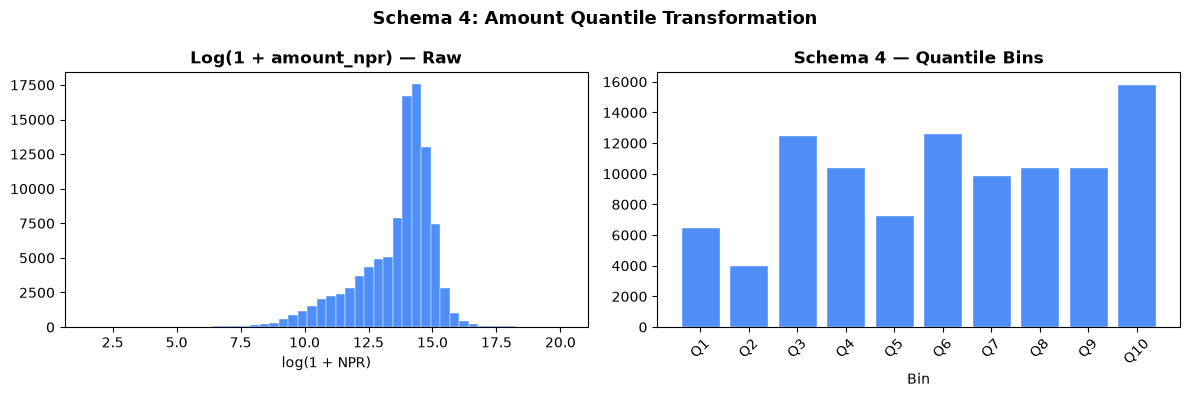

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 10 · Schema 4: Quantile Binning of Amount
# ──────────────────────────────────────────────────────────────────────────────

N_BINS = 10

schema4 = tx_canonical.copy()

# Step 1: log-transform (avoids log(0) since amount is clipped ≥ 0.01)
log_amount = np.log1p(schema4["amount_npr"].values.reshape(-1, 1))

# Step 2: fit quantile transformer (maps to [0,1] uniform)
qt4 = QuantileTransformer(n_quantiles=N_BINS, output_distribution="uniform", random_state=42)
quantile_vals = qt4.fit_transform(log_amount).flatten()

# Step 3: bin into N_BINS equal-width buckets → string labels "Q1"..."Q10"
bin_edges  = np.linspace(0, 1, N_BINS + 1)
bin_labels = [f"Q{i+1}" for i in range(N_BINS)]
schema4["amount_npr"] = pd.cut(
    quantile_vals, bins=bin_edges, labels=bin_labels, include_lowest=True
).astype(str)

print(f"Schema 4 shape   : {schema4.shape}")
print(f"\namount_npr distribution (quantile bins):")
print(schema4["amount_npr"].value_counts().sort_index())

# Visualise original vs binned
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(tx_canonical["amount_npr"]), bins=50, color="#4f8ef7", edgecolor="white", linewidth=0.3)
axes[0].set_title("Log(1 + amount_npr) — Raw", fontweight="bold")
axes[0].set_xlabel("log(1 + NPR)")
axes[1].bar(bin_labels, schema4["amount_npr"].value_counts().sort_index(), color="#4f8ef7", edgecolor="white")
axes[1].set_title("Schema 4 — Quantile Bins", fontweight="bold")
axes[1].set_xlabel("Bin")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Schema 4: Amount Quantile Transformation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Schema 5 — Cubic Root Transformation of Amount
Standardise `amount_npr` to zero mean / unit variance then apply cube root.
Softer correction than binning — preserves ordinality and is fully reversible.


Schema 5 shape   : (100222, 41)

Cbrt params: mean=1,769,234.80 NPR, std=5,005,345.50 NPR
Transformed amount_npr stats:
count    100222.000000
mean         -0.179576
std           0.574678
min          -0.707050
25%          -0.650216
50%          -0.473170
75%           0.409831
max           4.792693
Name: amount_npr, dtype: float64

Max inverse-transform error: 0.000000 NPR  ✓


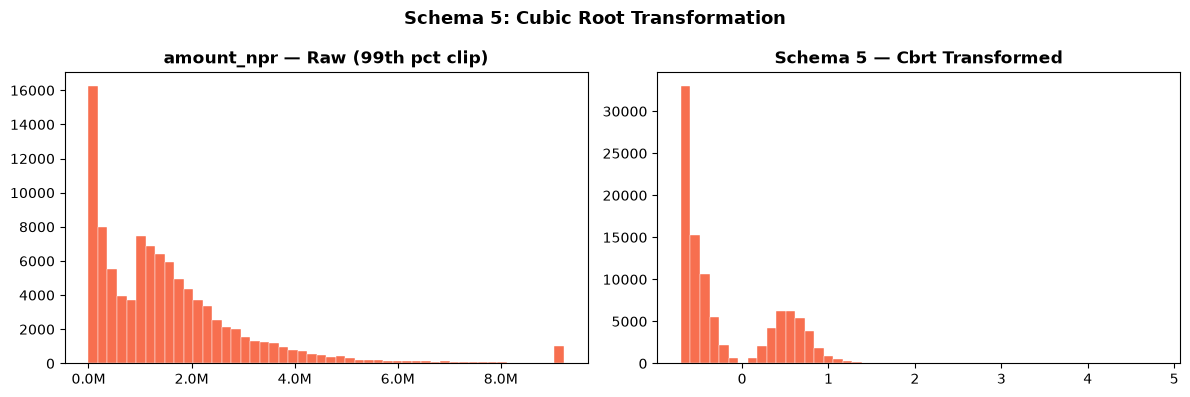

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 11 · Schema 5: Cubic Root Amount Transformation
# ──────────────────────────────────────────────────────────────────────────────

schema5 = tx_canonical.copy()

mu5  = schema5["amount_npr"].mean()
sig5 = schema5["amount_npr"].std()
if sig5 == 0: sig5 = 1.0

cbrt_params = {"mean": mu5, "std": sig5}
standardised = (schema5["amount_npr"] - mu5) / sig5
schema5["amount_npr"] = np.cbrt(standardised)

print(f"Schema 5 shape   : {schema5.shape}")
print(f"\nCbrt params: mean={mu5:,.2f} NPR, std={sig5:,.2f} NPR")
print(f"Transformed amount_npr stats:")
print(schema5["amount_npr"].describe())

# ── Verify inverse transform ───────────────────────────────────────────────────
recovered = (schema5["amount_npr"] ** 3) * cbrt_params["std"] + cbrt_params["mean"]
max_err = (recovered - tx_canonical["amount_npr"]).abs().max()
print(f"\nMax inverse-transform error: {max_err:.6f} NPR  ✓" if max_err < 0.01 else f"\nWarning: large error {max_err}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tx_canonical["amount_npr"].clip(upper=tx_canonical["amount_npr"].quantile(0.99)),
             bins=50, color="#f76f4f", edgecolor="white", linewidth=0.3)
axes[0].set_title("amount_npr — Raw (99th pct clip)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].hist(schema5["amount_npr"], bins=50, color="#f76f4f", edgecolor="white", linewidth=0.3)
axes[1].set_title("Schema 5 — Cbrt Transformed", fontweight="bold")
plt.suptitle("Schema 5: Cubic Root Transformation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Save All Outputs

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 12 · Save All Parquet Files
# ──────────────────────────────────────────────────────────────────────────────
%time

outputs = {
    "transactions.parquet":            tx_canonical,
    "accounts.parquet":                acc_can,
    "schema2_location.parquet":        schema2,
    "schema3_label_encoded.parquet":   schema3,
    "schema4_quantile_amount.parquet": schema4,
    "schema5_cbrt_amount.parquet":     schema5,
}

for fname, df in outputs.items():
    path = INTERIM_DIR / fname
    df.to_parquet(path, index=False)
    size_mb = path.stat().st_size / 1e6
    print(f"✓ {fname:45s}  {df.shape[0]:>7,} rows × {df.shape[1]:>3} cols  ({size_mb:.1f} MB)")

print("\n✓ All files written to:", INTERIM_DIR)


CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 5.01 μs
✓ transactions.parquet                           100,222 rows ×  41 cols  (7.7 MB)
✓ accounts.parquet                                65,339 rows ×  13 cols  (1.3 MB)
✓ schema2_location.parquet                       100,222 rows ×  38 cols  (7.7 MB)
✓ schema3_label_encoded.parquet                  100,222 rows ×  41 cols  (7.7 MB)
✓ schema4_quantile_amount.parquet                100,222 rows ×  41 cols  (6.9 MB)
✓ schema5_cbrt_amount.parquet                    100,222 rows ×  41 cols  (7.8 MB)

✓ All files written to: /home/red/Desktop/neural-sentinel/data/interim


## 7. Summary & Class Balance

  PHASE 2 CLEANING COMPLETE

  Total transactions  :    100,222
  Fraudulent (flag=1) :        336  (0.3353%)
  Legitimate (flag=0) :     99,886

  Fraud type breakdown:
fraud_type
None                 99886
transaction_fraud      281
aml_layering            37
aml_structuring         18

  Channel distribution:
channel
mobile_banking    42586
online_banking    31224
pos               21658
branch             4754

  Transaction type:
transaction_type
transfer               85335
remittance_outbound    10133
cash_out                3108
deposit                 1646

  Amount (NPR) stats:
count        100,222.00
mean       1,769,234.80
std        5,005,345.50
min                3.74
25%          393,273.09
50%        1,238,979.56
75%        2,113,781.75
max      552,796,380.22


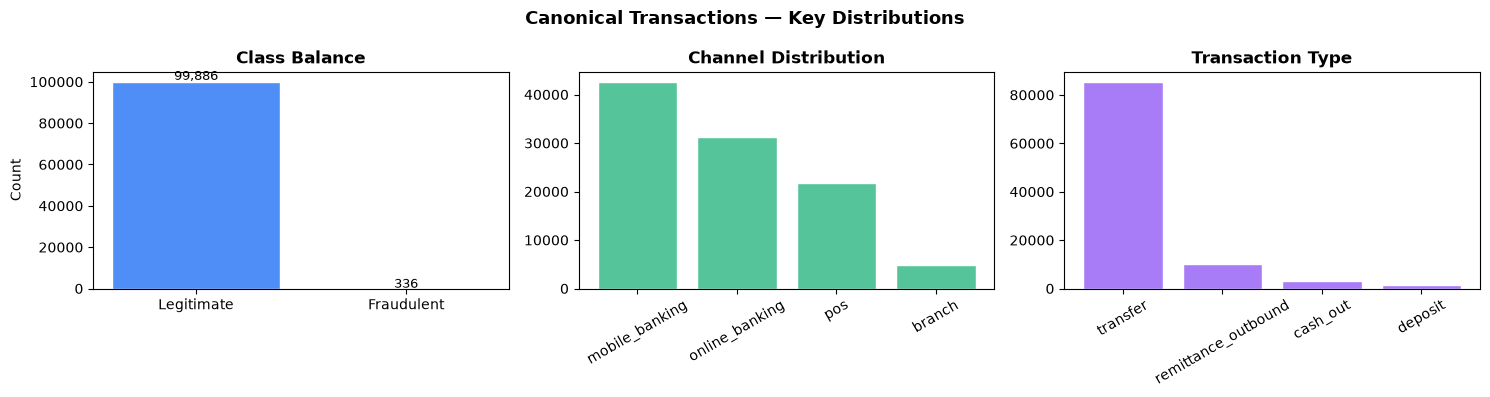


✓ Phase 2 notebook complete — next: phase3_benchmark_generators.ipynb


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 13 · Summary Statistics & Class Balance
# ──────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("  PHASE 2 CLEANING COMPLETE")
print("=" * 65)

fraud_rate = tx_canonical["is_fraud"].mean()
n_fraud    = tx_canonical["is_fraud"].sum()
n_total    = len(tx_canonical)

print(f"\n  Total transactions  : {n_total:>10,}")
print(f"  Fraudulent (flag=1) : {n_fraud:>10,}  ({fraud_rate:.4%})")
print(f"  Legitimate (flag=0) : {n_total-n_fraud:>10,}")

print(f"\n  Fraud type breakdown:")
print(tx_canonical["fraud_type"].value_counts(dropna=False).to_string())

print(f"\n  Channel distribution:")
print(tx_canonical["channel"].value_counts().to_string())

print(f"\n  Transaction type:")
print(tx_canonical["transaction_type"].value_counts().to_string())

print(f"\n  Amount (NPR) stats:")
print(tx_canonical["amount_npr"].describe().apply(lambda x: f"{x:,.2f}").to_string())

# ── Class balance bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Canonical Transactions — Key Distributions", fontsize=13, fontweight="bold")

# Fraud / legit
axes[0].bar(["Legitimate","Fraudulent"],
            [n_total-n_fraud, n_fraud], color=["#4f8ef7","#f76f4f"], edgecolor="white")
axes[0].set_title("Class Balance", fontweight="bold")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=9)

# Channel
ch_counts = tx_canonical["channel"].value_counts()
axes[1].bar(ch_counts.index, ch_counts.values, color="#56c49a", edgecolor="white")
axes[1].set_title("Channel Distribution", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

# Transaction type
tt_counts = tx_canonical["transaction_type"].value_counts()
axes[2].bar(tt_counts.index, tt_counts.values, color="#a97cf7", edgecolor="white")
axes[2].set_title("Transaction Type", fontweight="bold")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
print("\n✓ Phase 2 notebook complete — next: phase3_benchmark_generators.ipynb")
